<h1>NAO Teleconnections - Wind - UFS vs SEAS5</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
import numpy as np
from io import BytesIO
from PIL import Image
import scipy
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.datareader import UFS_DataReader, ERA5_DataReader
from src.regridder import Regrid
from src.util import timeutil, stats, nao

import warnings
warnings.filterwarnings('ignore')

<h3>User Configurables</h3>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/mslp/'

In [4]:
ufs_experiment = 'beta.0.1'

In [5]:
ufs_var = 'prmsl'
seas5_var = 'msl'

In [6]:
time_range = ("1994-01-01", "2021-12-01")
initmonth = 5

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = 3

In [7]:
# User can pick which dataset gives the "true" NAO phases.
# Normally we'd pick a verification dataset like era5
truthiness = 'era5'
# truthiness = 'ufs'
# truthiness = 'seas5'

In [8]:
# Scale variables for unit-matching
ufs_scaling_factor = 1
seas5_scaling_factor = 1

In [9]:
# For NAO, there are 2 reference locations:
region_1 = {'latmin': 65.0, 'lonmin': 331.2}
region_2 = {'latmin': 37.7, 'lonmin': 334.3}

In [10]:
# Filter ONI events per specific criteria.
strength = None  # For example, you can set strength = 'Weak', 'Moderate', 'Strong', or 'Very Strong'
oni_threshold = None  # For example, you can set oni_threshold = 3

In [11]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h2>First step is to calculate NAO Index</h2>

<h5>Get DataReaders</h5>

In [12]:
ufs_data_reader = dr.getDataReader(datasource='UFS',           
                                   experiment = ufs_experiment,
                                   # filename=f'experiments/phase_1/{ufs_model_1}/atm_monthly.zarr',                     
                                   model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/beta.0.1/atm_monthly.zarr


In [13]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [14]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [15]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [16]:
seas5_ds = seas5_data_reader.retrieve(var=seas5_var,
                                      initmonths=initmonth,
                                      time=time_range,
                                      member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                      ens_avg=True)

Taking Ensemble Average


In [17]:
ufs_ds = ufs_data_reader.retrieve(var=ufs_var,
                                  initmonths=initmonth,
                                  time=time_range,
                                  ens_avg=True)

Taking Ensemble Average


<h3>Calculate NAO Phases</h3>

In [18]:
if truthiness == 'era5':
    
    print('Processing ERA5 as NAO truth.')
    # If ERA5 verification data is chosen as the truth,
    # then we need to read these data in only for this step, and nothing further.
    era5_var = 'mean_sea_level_pressure'
    era5_data_reader = dr.getDataReader(datasource='ERA5')
    
    era5_ds = timeutil.match_time_to_leads(verif_ds=era5_data_reader.dataset(),
                                           ufs_ds=ufs_ds)
    
    era5_nao_object = nao.NAO(ds=era5_ds)
    era5_nao_object.calc_phases(var=era5_var)
    
    # Convert these phases to init+lead coordinates based on our chosen initmonth
    era5_nao_object.convert_to_initlead(initmonth=initmonth)
    
    # Store positive and negative phase init+leads
    positive_exclude_initleads = era5_nao_object.positive_exclude_initleads
    negative_exclude_initleads = era5_nao_object.negative_exclude_initleads
    
elif truthiness == 'ufs':
    
    print('Processing UFS as NAO truth.')
    ufs_nao_object = nao.NAO(ds=ufs_ds)
    ufs_nao_object.calc_phases(var=ufs_var)
    
    # Store positive and negative phase init+leads
    positive_exclude_initleads = ufs_nao_object.positive_exclude_initleads
    negative_exclude_initleads = ufs_nao_object.negative_exclude_initleads
    
elif truthiness == 'seas5':
    
    print('Processing SEAS5 as NAO truth.')
    seas5_nao_object = nao.NAO(ds=seas5_ds)
    seas5_nao_object.calc_phases(var=seas5_var)   
    
    # Store positive and negative phase init+leads
    positive_exclude_initleads = seas5_nao_object.positive_exclude_initleads
    negative_exclude_initleads = seas5_nao_object.negative_exclude_initleads

Processing ERA5 as NAO truth.
No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr
Results stored in:
<self>.positive_exclude_months
and
<self>.negative_exclude_months
Results stored in:
<self>.positive_exclude_initleads
and
<self>.negative_exclude_initleads


<h2>Now that NAO Index is calculated, we can form Wind composites</h2>

In [19]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/uv/'

In [20]:
ufs_var = ['u', 'v']
seas5_var = ['u', 'v']
lev = 200

In [21]:
ufs_data_reader = dr.getDataReader(datasource='UFS',           
                                   experiment = ufs_experiment,
                                   # filename=f'experiments/phase_1/{ufs_model_1}/atm_monthly.zarr',                     
                                   model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/beta.0.1/atm_monthly.zarr


In [22]:
# Our Regridder requires 1 UFS-type data reader and,
# if not another UFS model, a time-based model like ERA5.  

# What we will do is instantiate a UFS data reader,
# but then supplant its data with the SEAS5 dataset.
seas5_data_reader = dr.getDataReader(datasource='UFS',                  
                                     experiment = 'baseline',
                                     model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [23]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [24]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [25]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                 'number': 'member',
                                 'pressure_level': 'lev'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member',
                            'pressure_level': 'lev'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader.update(ds=seas5_ds)

Dataset updated.


In [26]:
ufs_ds = ufs_data_reader.retrieve(var=ufs_var,
                                  lev=lev,
                                  time=time_range,
                                  initmonths=initmonth,
                                  lead=(min(leads), max(leads)),
                                  ens_avg=True)

Taking Ensemble Average


In [27]:
seas5_ds = seas5_data_reader.retrieve(var=seas5_var,
                                      lev=lev,
                                      time=time_range,
                                      initmonths=initmonth,
                                      lead=(min(leads), max(leads)),
                                      member=(0, 24), # We know seas5 hindcast has members 0-24
                                      ens_avg=True)

Taking Ensemble Average


In [28]:
# Scale fields.
ufs_ds = ufs_ds * ufs_scaling_factor                                                                          
seas5_ds = seas5_ds * seas5_scaling_factor

In [29]:
# Update
ufs_data_reader.update(ds=ufs_ds)
seas5_data_reader.update(ds=seas5_ds)

Dataset updated.
Dataset updated.


In [30]:
len(ufs_data_reader.dataset().lat.values)

361

In [31]:
len(seas5_data_reader.dataset().lat.values)

180

In [32]:
regridder = Regrid.Regrid(data_reader1=ufs_data_reader,                                                              
                          data_reader2=seas5_data_reader,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
Both datasets are UFS, so the .resample() method is disabled.

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (UFS_DataReader): lat 361, lon 720
Output grid shape data_reader2 (UFS_DataReader): lat 180, lon 360
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
Both datasets are UFS, so the .align() method is disabled.


In [33]:
# REGRID.
regridder.regrid(var=ufs_var)

Regridding data_reader1 grid (UFS_DataReader) onto data_reader2 grid (UFS_DataReader)
Running spherical harmonics on u and v
Completed sperical harmonics in 0.01 minutes.
Regrid results stored in <RegridObj>.regridded


In [34]:
# Get Xarray dataset objects.
if regridder.highres_grid == 1:
    ufs_ds = regridder.regridded.dataset()
    seas5_ds = seas5_data_reader.dataset()
    
elif regridder.highres_grid == 2:
    ufs_ds = ufs_data_reader.dataset()
    seas5_ds = regridder.regridded.dataset()

In [35]:
ufs_data_reader.update(ds=ufs_ds)
seas5_data_reader.update(ds=seas5_ds)

Dataset updated.
Dataset updated.


<h2>Ready for calculations</h2>

In [36]:
# 1 -> UFS
# 2 -> SEAS5
ds1_positive_statistics = stats.calc_composite_layers(data_reader=ufs_data_reader,
                                                      var=ufs_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=positive_exclude_initleads)

ds1_negative_statistics = stats.calc_composite_layers(data_reader=ufs_data_reader,
                                                      var=ufs_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=negative_exclude_initleads)

ds2_positive_statistics = stats.calc_composite_layers(data_reader=seas5_data_reader,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=positive_exclude_initleads)

ds2_negative_statistics = stats.calc_composite_layers(data_reader=seas5_data_reader,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=negative_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


<h3>Run t-tests</h3>

In [37]:
ds1_positive_statistics = ds1_positive_statistics.squeeze(dim=['lev'])
ds1_negative_statistics = ds1_negative_statistics.squeeze(dim=['lev'])
ds2_positive_statistics = ds2_positive_statistics.squeeze(dim=['lev'])
ds2_negative_statistics = ds2_negative_statistics.squeeze(dim=['lev'])

In [38]:
# Get position of init and lead axes
dims = list(ds1_positive_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [39]:
# POSITIVE
anomaly_tstatistic_positive, anomaly_pvalue_positive =\
    scipy.stats.ttest_ind(a=ds1_positive_statistics['anomaly'].values,
                          b=ds2_positive_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# NEGATIVE
anomaly_tstatistic_negative, anomaly_pvalue_negative =\
    scipy.stats.ttest_ind(a=ds1_negative_statistics['anomaly'].values,
                          b=ds2_negative_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [40]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_positive': (('lat', 'lon'), anomaly_pvalue_positive),
        'anomaly_pvalue_negative': (('lat', 'lon'), anomaly_pvalue_negative)
        
    },
    coords={
        'lat': ufs_data_reader.dataset().lat.values,
        'lon': ufs_data_reader.dataset().lon.values
    }
)

<h3>Anomaly</h3>

In [41]:
# This is the DataArray for the Composite
ds1_positive_composite = ds1_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_negative_composite = ds1_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_positive_composite = ds2_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_negative_composite = ds2_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
positive_ds2_minus_ds1 = ds2_positive_composite - ds1_positive_composite
negative_ds2_minus_ds1 = ds2_negative_composite - ds1_negative_composite

# Calculate Correlations
positive_corr = xr.corr(ds1_positive_composite, ds2_positive_composite).values.item()
negative_corr = xr.corr(ds1_negative_composite, ds2_negative_composite).values.item()

<h5>Make labels for plots</h5>

In [42]:
def count_phases(da):
    '''Ad hoc function:  Count the number of init leads with defined data.'''
    n_phases = 0
    # Loop over init-leads
    for this_init in da.init.values:
        for this_lead in da.lead.values:

            # Check if all nan
            if not np.isnan(da.sel(init=this_init, lead=this_lead).values).all():
                n_phases += 1

    return n_phases

In [43]:
n_ufs_positive_phases = f"# Positive Phases: {count_phases(ds1_positive_statistics['anomaly'])}"
n_ufs_negative_phases = f"# Negative Phases: {count_phases(ds1_negative_statistics['anomaly'])}"

n_seas5_positive_phases = f"# Positive Phases: {count_phases(ds2_positive_statistics['anomaly'])}"
n_seas5_negative_phases = f"# Negative Phases: {count_phases(ds2_negative_statistics['anomaly'])}"

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
positive_corr_label = f'corr: {positive_corr:.2f}'
negative_corr_label = f'corr: {negative_corr:.2f}'

<h3>Generate figures</h3>

In [44]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'K',
               'cmap': 'custom_btr',
               'topleft_label': initlead_label, 
               'region': None,
               'dpi': 200}

plot1 = stats.plot_composite(da = ds1_positive_composite,
                             title=f'{ufs_data_reader.datasource} Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-4, vmax=4,
                             subtitle=n_ufs_positive_phases, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = stats.plot_composite(da = ds1_negative_composite,
                             title=f'{ufs_data_reader.datasource} Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-4, vmax=4,
                             subtitle=n_ufs_negative_phases, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = stats.plot_composite(da = ds2_positive_composite,
                             title=f'SEAS5 Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-4, vmax=4,
                             subtitle=n_seas5_positive_phases, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = stats.plot_composite(da = ds2_negative_composite,
                             title=f'SEAS5 Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-4, vmax=4,
                             subtitle=n_seas5_negative_phases, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = stats.plot_composite(da = positive_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_positive'],
                             shading_threshold = 0.05,
                             title=f'SEAS5 minus {ufs_data_reader.datasource} Zonal Wind Anomaly lev={lev} (Positive NAO Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=positive_corr_label,
                             **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = stats.plot_composite(da = negative_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_negative'],
                             shading_threshold = 0.05,
                             title=f'SEAS5 minus {ufs_data_reader.datasource} Zonal Wind Anomaly lev={lev} (Negative NAO Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=negative_corr_label,
                             **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

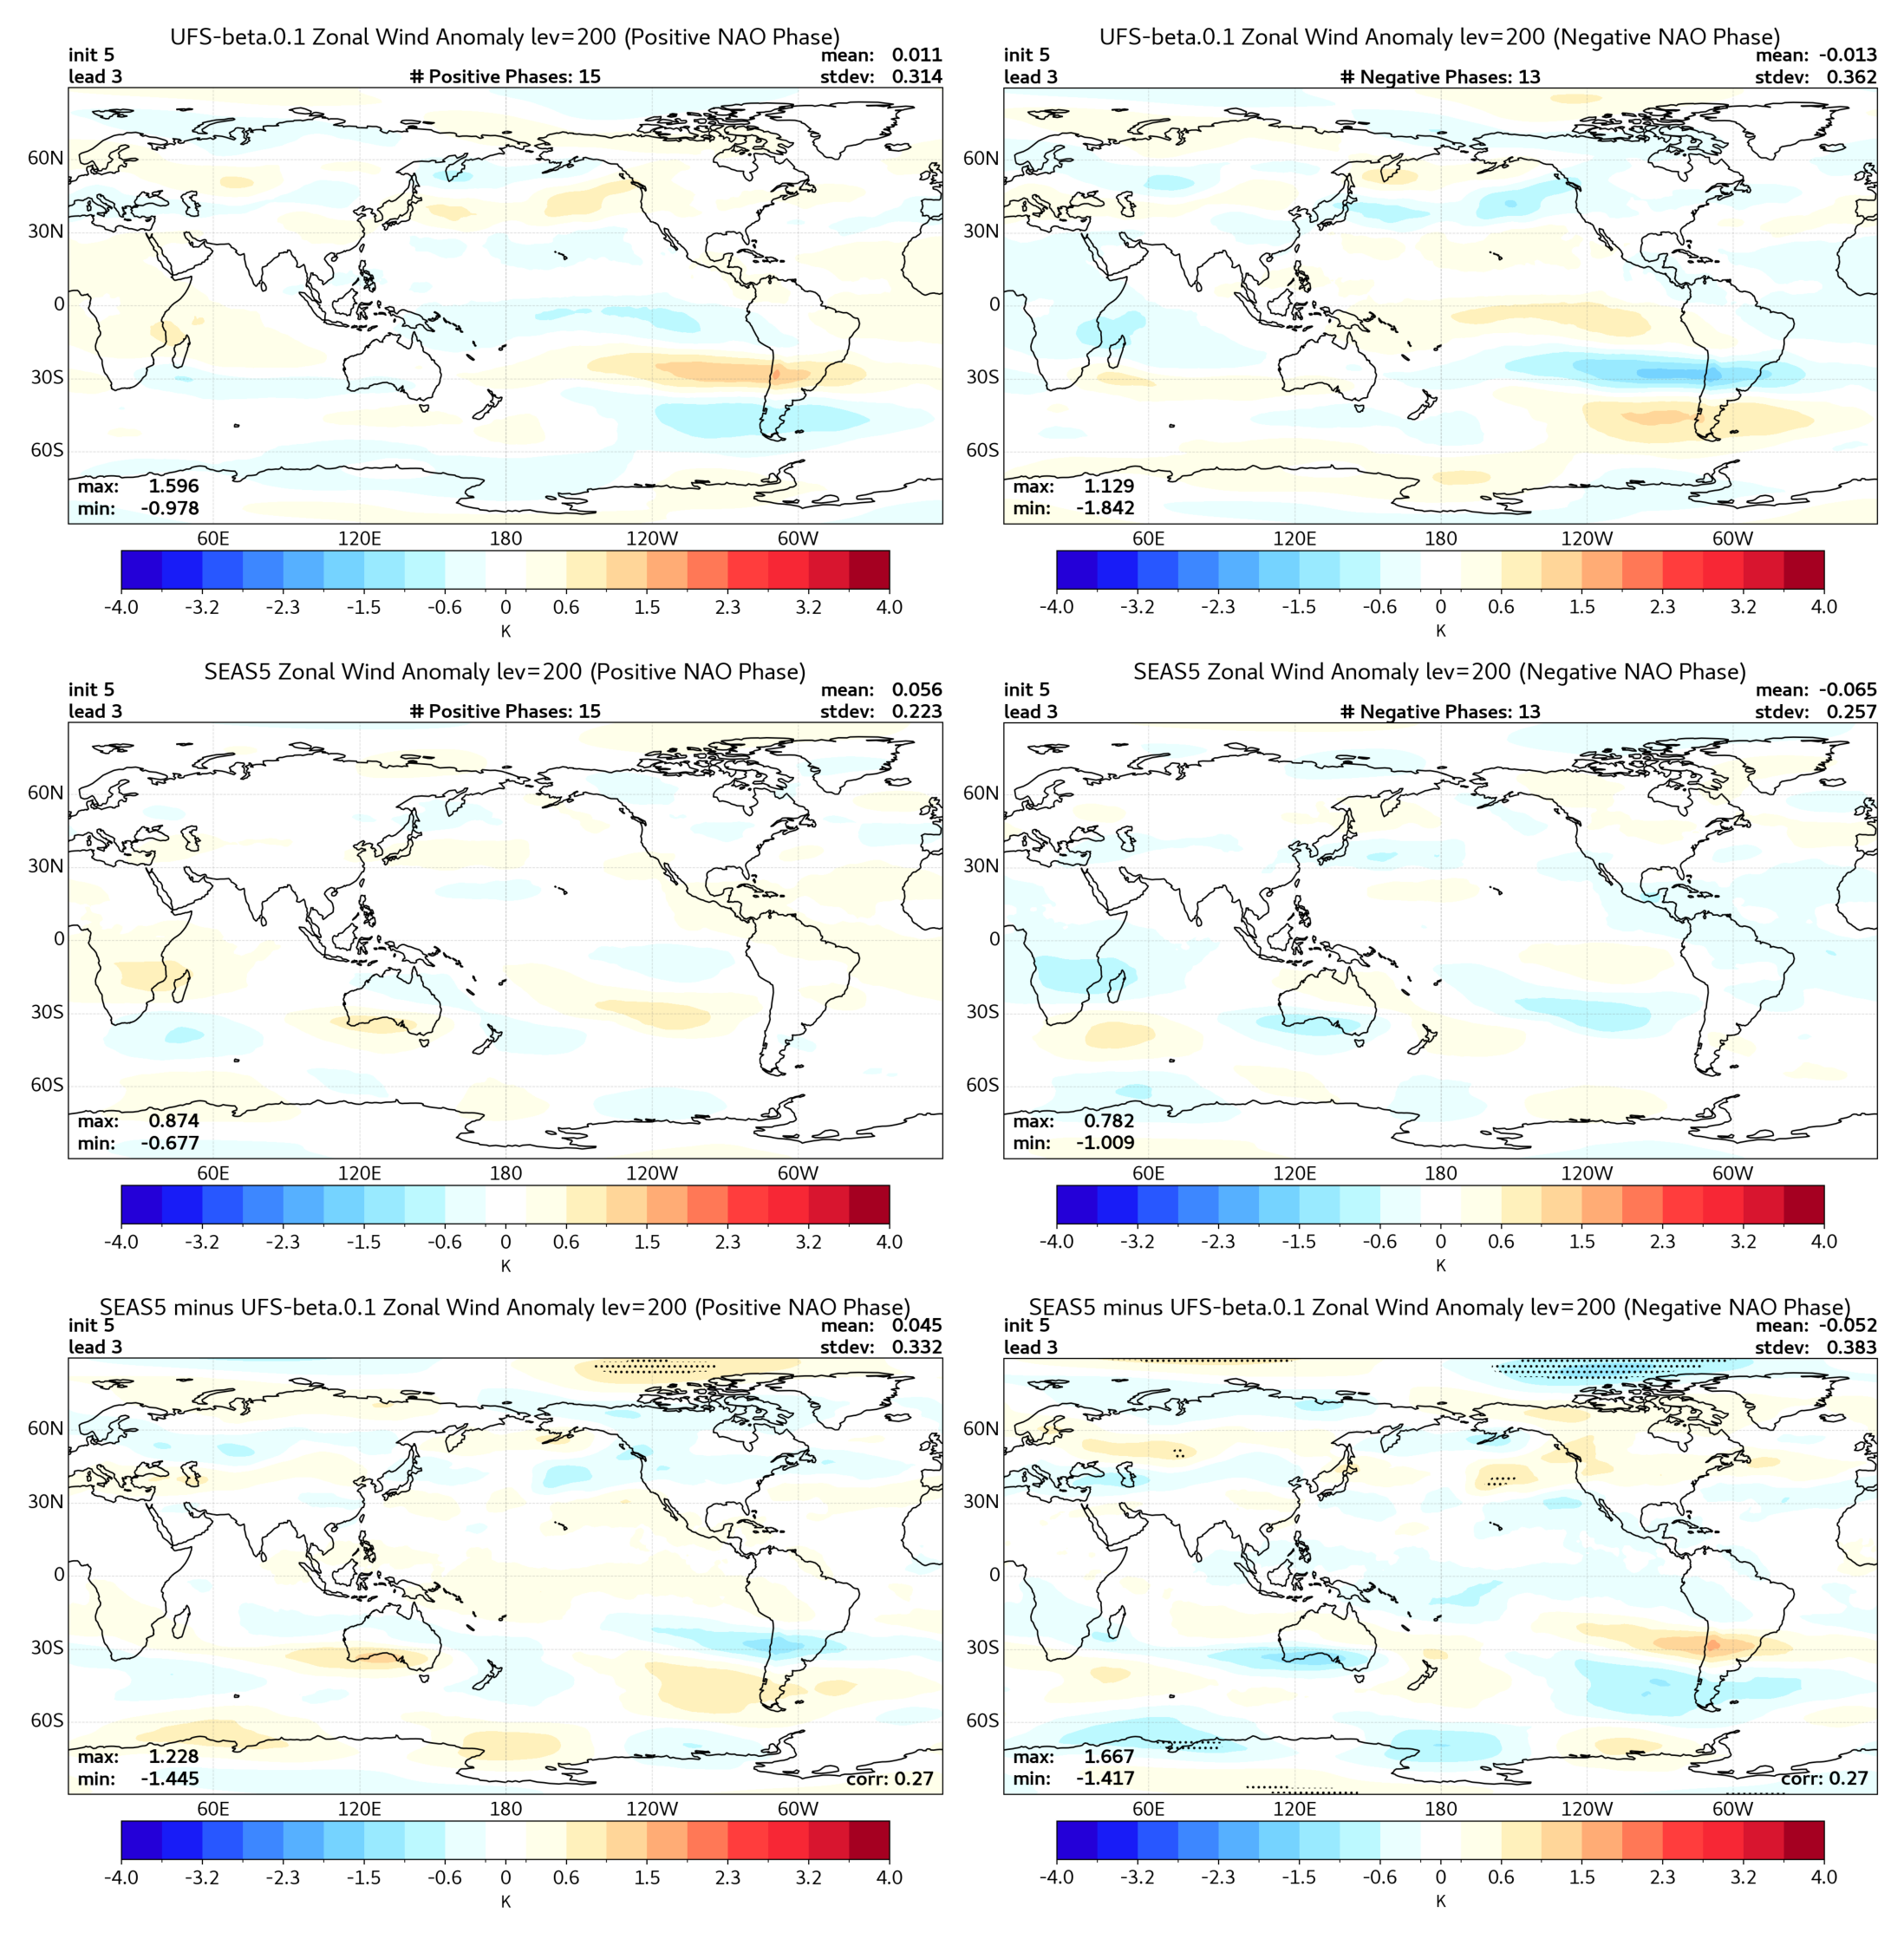

In [45]:
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axs[0, 0].imshow(image1)
axs[0, 0].axis('off')

axs[0, 1].imshow(image2)
axs[0, 1].axis('off')

axs[1, 0].imshow(image3)
axs[1, 0].axis('off')

axs[1, 1].imshow(image4)
axs[1, 1].axis('off')

axs[2, 0].imshow(image5)
axs[2, 0].axis('off')

axs[2, 1].imshow(image6)
axs[2, 1].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=.05)
plt.show()
